# Common Libraries

In [1]:
import os, sys, shutil, pickle
import numpy as np
import matplotlib.pylab as plt
if shutil.which("nvidia-smi") is not None:
    os.environ["MUJOCO_GL"] = "egl"
import mujoco

# Custom Libraries

In [2]:
myoconverter_path = "/home/seojin/biomechanics_tools/myoconverter"
sys.path.append(myoconverter_path)
from myoconverter.optimization.utils.UtilsMujoco import getMuscleForceLengthCurvesSim

In [14]:
def curveplotForceLength(muscle,
                         length_mtu_osim,
                         mtu_force_osim,
                         mtu_force_osim_passive,
                         length_mtu_mjc,
                         mtu_length_mjc_passive,
                         mjc_force_mjc,
                         mtu_force_mjc_passive,
                         act_arr,
                         is_save_result = False):
    """
    Plot the muscle force length curves        
    """

    actMesh = len(act_arr)

    f = plt.figure(figsize=(10, 8))
    ax1 = f.add_subplot(1, 2, 1)
    ax2 = f.add_subplot(1, 2, 2)

    # find the minimal and maximum values in mjc and osim mf data, to set the axis equal
    # osim and mjc model have oppsite signs in muscle forces
    max_mf = np.maximum(mtu_force_osim.max(), -mjc_force_mjc.min())
    min_mf = np.minimum(np.minimum(mtu_force_osim.min(), -mjc_force_mjc.max()), 0)
    
    max_ml = np.maximum(length_mtu_osim.max(), length_mtu_mjc.max())
    min_ml = np.minimum(length_mtu_osim.min(), length_mtu_mjc.min())

    osim_accend_index = np.argsort(length_mtu_osim)
    
    for c in range(actMesh):
        line_color = tuple([c, c, actMesh]/np.sqrt(2*c**2 + actMesh**2))

        mjc_accend_index = np.argsort(length_mtu_mjc[c])
        mjc_accend_passive_index = np.argsort(mtu_length_mjc_passive[c])

        ax1.plot(length_mtu_osim[osim_accend_index]*100, mtu_force_osim[c][osim_accend_index], marker = "s", color=line_color)
        ax1.plot(length_mtu_osim[osim_accend_index]*100, mtu_force_osim_passive[c][osim_accend_index], linestyle = "dashed",\
                    marker = "o", color=line_color)

    ax1.set_ylabel("Muscle forces (N)")
    ax1.set_xlabel(" MTU length (cm)")
    ax1.set_ylim([0.95*min_mf, 1.05*max_mf])
    ax1.set_xlim([0.95*min_ml*100, 1.05*max_ml*100])
    ax1.set_title("OSIM")

    for c in range(actMesh):
        line_color = tuple([c, c, actMesh]/np.sqrt(2*c**2 + actMesh**2))
        ax2.plot(length_mtu_mjc[c][mjc_accend_index]*100, -mjc_force_mjc[c][mjc_accend_index], marker = "s", color=line_color)
        ax2.plot(mtu_length_mjc_passive[c][mjc_accend_passive_index]*100, -mtu_force_mjc_passive[c][mjc_accend_index], linestyle = "dashed",\
                    marker = "o", color=line_color)

    plt.legend(["Total force", "Passive force"])
    ax2.set_ylabel("Muscle forces (N)")
    ax2.set_xlabel(" MTU length (cm)")
    ax2.set_ylim([0.95*min_mf, 1.05*max_mf])
    ax2.set_xlim([0.95*min_ml*100, 1.05*max_ml*100])
    ax2.set_title("MJC")

    plt.suptitle(muscle)

    if is_save_result:
        save_path = os.path.join(muscle_force_dir_path, f"{muscle}.svg")
        f.savefig(save_path, format = "svg")
        plt.close(f)
        print(f"save: {save_path}")

# Params

In [15]:
model_path = "/mnt/sdb2/DeepProprioception/Projects/DP01_emg/Myosuite/scaled_model/scaled_model_cvt2.xml"
muscle_dir_path = "/mnt/ext1/seojin/temp/MOBL_ARMS_41/Step3_muscleKinetics" # "/mnt/ext1/seojin/temp/myoconverter"

muscle_name = "TMIN"
is_save_result = False

# Constants

In [16]:
muscle_force_dir_path = os.path.join(muscle_dir_path, "muscle_forces")
os.makedirs(muscle_force_dir_path, exist_ok = True)

muscle_info_path = os.path.join(muscle_dir_path, f"{muscle_name}.pkl")

# Load model

In [17]:
mjc_model = mujoco.MjModel.from_xml_path(model_path)
muscle_names = [mujoco.mj_id2name(mjc_model, mujoco.mjtObj.mjOBJ_ACTUATOR, i) for i in range(mjc_model.nu)]

# Load muscle params

In [18]:
with open(muscle_info_path, "rb+") as muscle_file:
    muscle_para_opt = pickle.load(muscle_file)

# generate force-length comparison plot for each muscle
mtu_force_osim = muscle_para_opt['mtu_force_osim']
mtu_force_osim_passive = muscle_para_opt['pas_force_osim']
mtu_length_osim = muscle_para_opt['mtu_length_osim']
joints = muscle_para_opt['jit_uniq']
mjc_jnt_arr = muscle_para_opt['mjc_jit_list_set']
act_arr = muscle_para_opt['act_list']

In [19]:
# generate muscle force length curves in mujoco
mtu_force_mjc, mtu_length_mjc = getMuscleForceLengthCurvesSim(mjc_model,
                                                              muscle_name,
                                                              joints,
                                                              mjc_jnt_arr,
                                                              act_arr)

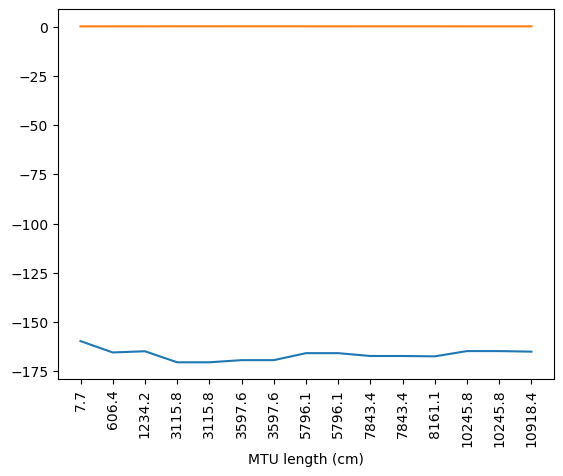

In [55]:
plt.plot(mtu_force_mjc[0])
plt.plot(mtu_length_mjc[0])
plt.xticks(np.arange(len(mtu_length_osim)), [f"{e:.1f}" for e in mtu_length_osim * 100], rotation = 90)
plt.xlabel("MTU length (cm)")
None

In [20]:
# get the passive muscle force length curves in mujoco
mtu_force_mjc_passive, mtu_length_mjc_passive = getMuscleForceLengthCurvesSim(mjc_model, 
                                                                              muscle_name,
                                                                              joints,
                                                                              mjc_jnt_arr,
                                                                              [0])

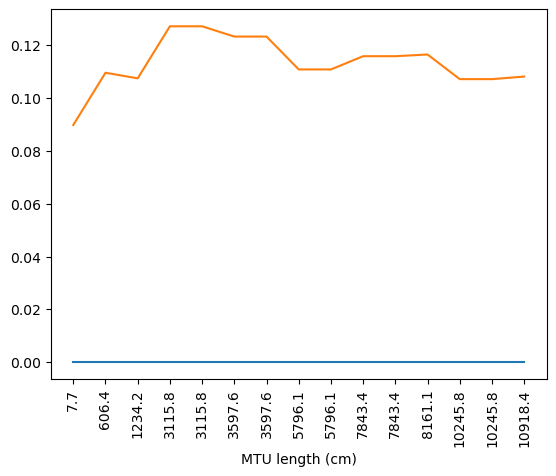

In [54]:
plt.plot(mtu_force_mjc_passive[0])
plt.plot(mtu_length_mjc_passive[0])
plt.xticks(np.arange(len(mtu_length_osim)), [f"{e:.1f}" for e in mtu_length_osim * 100], rotation = 90)
plt.xlabel("MTU length (cm)")
None

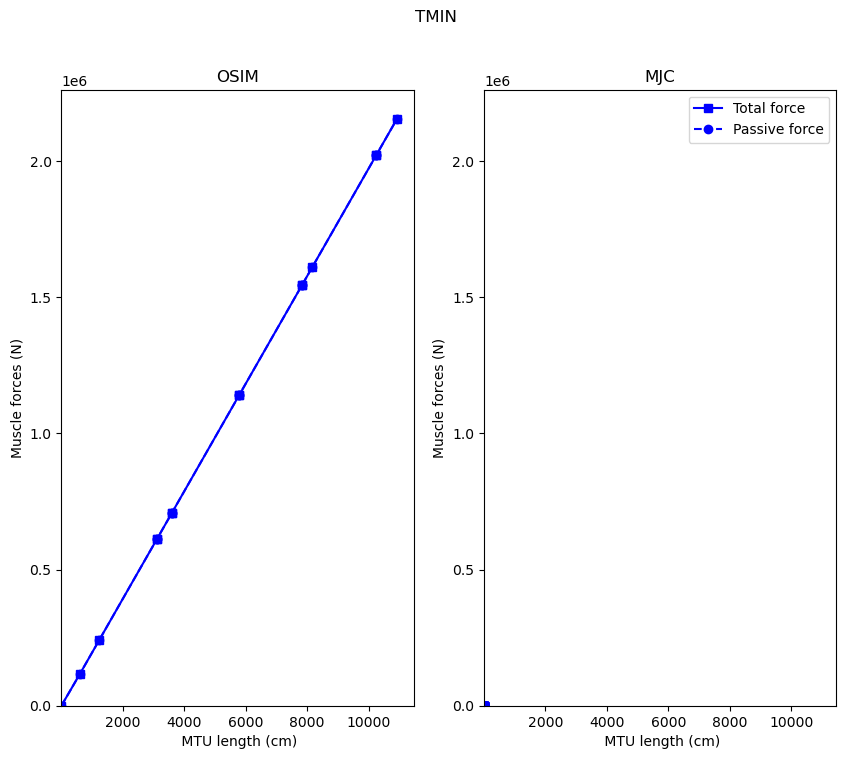

In [21]:
# plot the force comparison curves
curveplotForceLength(muscle_name,
                     mtu_length_osim,
                     mtu_force_osim,
                     mtu_force_osim_passive,
                     mtu_length_mjc,
                     mtu_length_mjc_passive,
                     mtu_force_mjc,
                     mtu_force_mjc_passive,
                     act_arr)

In [23]:
# save mjc forve lenth curve as well
muscle_para_opt['mtu_force_mjc'] = mtu_force_mjc
muscle_para_opt['mtu_force_mjc_passive'] = mtu_force_mjc_passive
muscle_para_opt['mtu_length_mjc'] = mtu_length_mjc
muscle_para_opt['mtu_length_mjc_passive'] = mtu_length_mjc_passive

In [24]:
if is_save_result:
    with open(muscle_info_path, "rb+") as muscle_file:
        pickle.dump(muscle_para_opt, muscle_file)
        print(f"save: {muscle_info_path}")